# Capstone Project: Supermarket Sales Analytics

**Customer segmentation, sales forecasting and order value prediction**

Week 12 - Capstone Project and Wrap Up

## 1. Problem statement

A supermarket has several years of order data. The business wants to use it to answer three practical questions:

1. **Who are our most valuable customers?** Can we split customers into groups so marketing can treat them differently?
2. **How much will we sell in the next few months?** A good forecast helps with stock and staff planning.
3. **What drives the value of a single order?** Can we predict the sales value of an order from information we know when it is placed?

**How I will judge success**

- The forecasting model should beat simple baselines on the last 6 months of data, which the model never sees during training.
- The order value model should beat a "just predict the average" baseline on unseen orders.
- The customer groups should be clearly different from each other and useful for a business decision.

**Approach**

`Load data -> Clean -> Feature creation -> EDA -> Customer segmentation (RFM + KMeans) -> Monthly sales forecasting -> Order value prediction -> Findings`

This project builds on my Week 9 (time series) and Week 11 (supermarket sales prediction) work, but goes further: better validation, more models, and a customer segmentation part.

## 2. Setup

In [1]:
import os
import json
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)

# Every important number is saved in this dictionary and written to a file at the end
results = {}


def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3. Load the data

The dataset is the supermarket sales data from Week 11 (`supermarket.csv`). Each row is one product line of an order, with the order date, ship date, customer, location, product category and the sales value.

Put the file in the `data/` folder before running.

In [2]:
DATA_PATHS = ["data/supermarket.csv", "supermarket.csv"]
data_path = next((p for p in DATA_PATHS if os.path.exists(p)), None)

if data_path is None:
    raise FileNotFoundError("Put supermarket.csv inside the data/ folder (see data/README.md).")

raw = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape:", raw.shape)
raw.head()

Loaded: data/supermarket.csv
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
required = [
    "Order ID", "Order Date", "Ship Date", "Ship Mode", "Customer ID",
    "Segment", "Region", "State", "Category", "Sub-Category", "Sales",
]
missing_cols = [c for c in required if c not in raw.columns]
assert not missing_cols, f"These columns are missing from the data: {missing_cols}"

raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
print("Missing values per column:")
print(raw.isnull().sum())

dup_cols = [c for c in raw.columns if c != "Row ID"]
print("\nDuplicate rows (ignoring Row ID):", raw.duplicated(subset=dup_cols).sum())

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows (ignoring Row ID): 1


In [5]:
raw.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 4. Data cleaning

Steps:

1. Convert the date columns to real dates (the file stores them as text).
2. Drop rows that are missing an important field.
3. Remove exact duplicate rows.
4. Create the date and shipping features.
5. Remove impossible values (ship date before order date, sales that are zero or negative).

I keep a log of how many rows each step removes, so the cleaning is transparent.

In [6]:
def parse_dates(s):
    # The file usually stores dates as day/month/year. If that fails, let pandas guess.
    d = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
    if d.isna().mean() > 0.5:
        d = pd.to_datetime(s, errors="coerce")
    return d


df = raw.copy()
cleaning_log = {"Rows at start": len(df)}

# 1. dates
df["Order Date"] = parse_dates(df["Order Date"])
df["Ship Date"] = parse_dates(df["Ship Date"])

# 2. missing key fields
before = len(df)
df = df.dropna(subset=required)
cleaning_log["Removed: missing key fields"] = before - len(df)

# 3. duplicates
before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != "Row ID"])
cleaning_log["Removed: duplicate rows"] = before - len(df)

# 4. features
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Weekday"] = df["Order Date"].dt.dayofweek
df["Weekday Name"] = df["Order Date"].dt.day_name()

# 5. impossible values
before = len(df)
df = df[df["Shipping Days"] >= 0]
cleaning_log["Removed: ship date before order date"] = before - len(df)

before = len(df)
df = df[df["Sales"] > 0]
cleaning_log["Removed: sales <= 0"] = before - len(df)

df = df.reset_index(drop=True)
cleaning_log["Rows after cleaning"] = len(df)

pd.Series(cleaning_log, name="rows").to_frame()

,rows
Rows at start,9800
Removed: missing key fields,0
Removed: duplicate rows,1
Removed: ship date before order date,0
Removed: sales <= 0,0
Rows after cleaning,9799


In [7]:
if "Postal Code" in df.columns:
    print("Postal Code is missing in", int(df["Postal Code"].isna().sum()), "rows. It is not used in the models, so I leave it as it is.")

results["rows_raw"] = int(cleaning_log["Rows at start"])
results["rows_clean"] = int(len(df))
results["date_min"] = str(df["Order Date"].min().date())
results["date_max"] = str(df["Order Date"].max().date())
print("Date range:", results["date_min"], "to", results["date_max"])

Postal Code is missing in 11 rows. It is not used in the models, so I leave it as it is.
Date range: 2015-01-03 to 2018-12-30


## 5. Exploratory data analysis (EDA)

First the headline numbers, then sales over time, then sales by product and location.

In [8]:
total_sales = df["Sales"].sum()
n_orders = df["Order ID"].nunique()
n_customers = df["Customer ID"].nunique()
avg_order_value = df.groupby("Order ID")["Sales"].sum().mean()

print(f"Total sales          : {total_sales:,.0f}")
print(f"Number of orders     : {n_orders:,}")
print(f"Number of customers  : {n_customers:,}")
print(f"Average order value  : {avg_order_value:,.2f}")
print(f"Average line sales   : {df['Sales'].mean():,.2f}  (median {df['Sales'].median():,.2f})")

results.update(
    total_sales=float(total_sales),
    n_orders=int(n_orders),
    n_customers=int(n_customers),
    avg_order_value=float(avg_order_value),
)

Total sales          : 2,261,255
Number of orders     : 4,922
Number of customers  : 793
Average order value  : 459.42
Average line sales   : 230.76  (median 54.48)


### 5.1 Sales over time

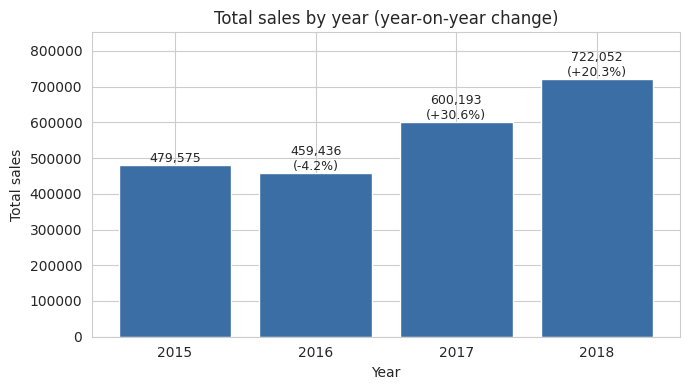

In [9]:
yearly = df.groupby("Order Year")["Sales"].sum()
yoy = yearly.pct_change() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(yearly.index.astype(str), yearly.values, color="#3b6ea5")
for i, (year, value) in enumerate(yearly.items()):
    label = f"{value:,.0f}" if np.isnan(yoy[year]) else f"{value:,.0f}\n({yoy[year]:+.1f}%)"
    ax.text(i, value, label, ha="center", va="bottom", fontsize=9)
ax.set_title("Total sales by year (year-on-year change)")
ax.set_xlabel("Year")
ax.set_ylabel("Total sales")
ax.set_ylim(0, yearly.max() * 1.18)
save_fig("01_sales_by_year")

results["yearly_sales"] = {str(k): float(v) for k, v in yearly.items()}
results["yoy_growth_pct"] = {str(k): float(v) for k, v in yoy.dropna().items()}

Strongest month on average: November
Weakest month on average  : February


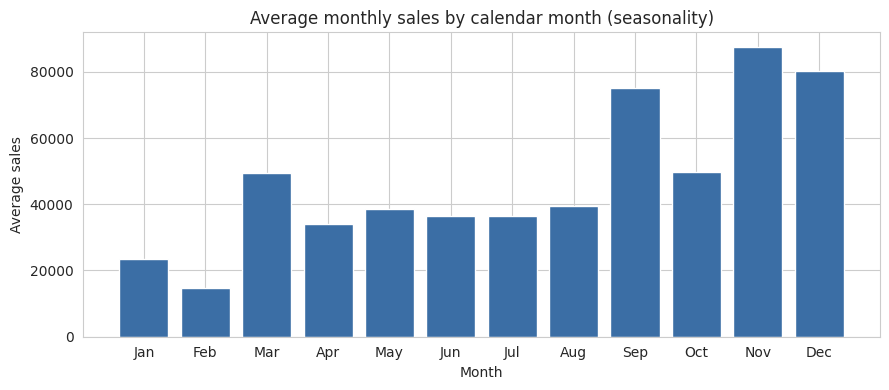

In [10]:
month_totals = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
season = month_totals.groupby("Order Month")["Sales"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([calendar.month_abbr[m] for m in season.index], season.values, color="#3b6ea5")
ax.set_title("Average monthly sales by calendar month (seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Average sales")
save_fig("02_seasonality")

best_month = calendar.month_name[int(season.idxmax())]
worst_month = calendar.month_name[int(season.idxmin())]
print("Strongest month on average:", best_month)
print("Weakest month on average  :", worst_month)
results["best_month"] = best_month
results["worst_month"] = worst_month

### 5.2 Sales by product, customer and location

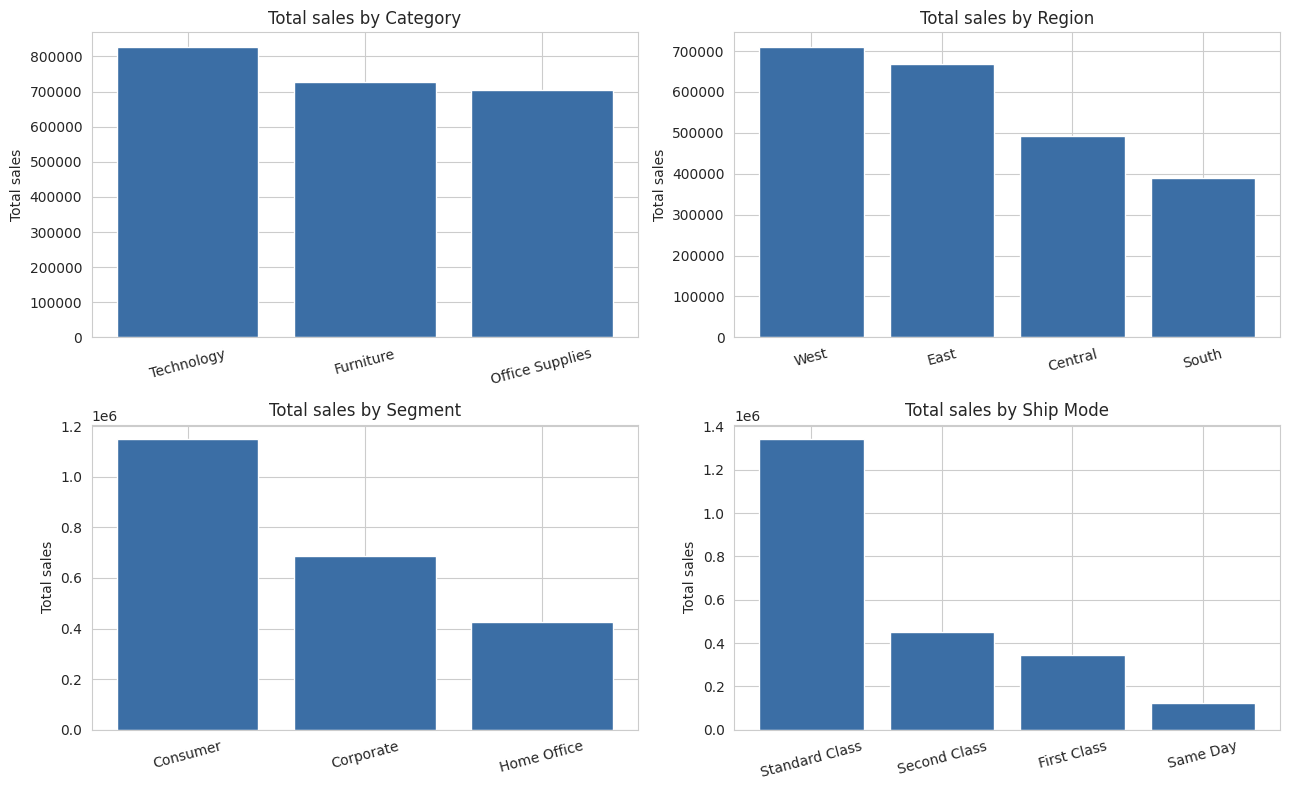

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ["Category", "Region", "Segment", "Ship Mode"]):
    s = df.groupby(col)["Sales"].sum().sort_values(ascending=False)
    ax.bar(s.index, s.values, color="#3b6ea5")
    ax.set_title(f"Total sales by {col}")
    ax.set_ylabel("Total sales")
    ax.tick_params(axis="x", rotation=15)
save_fig("03_sales_by_group")

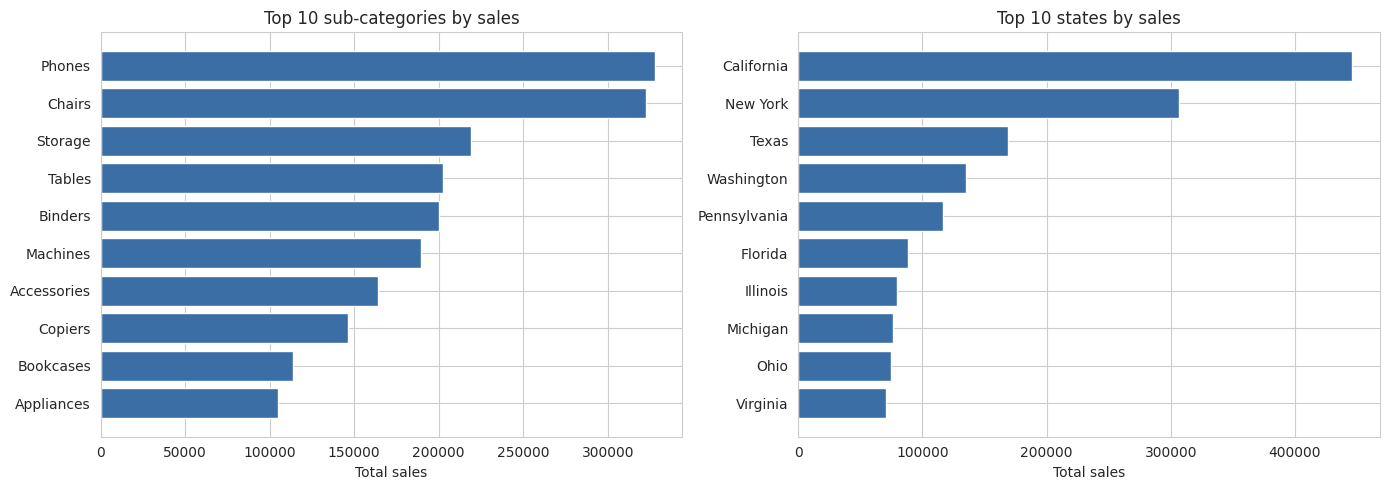

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sub = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
axes[0].barh(sub.index[::-1], sub.values[::-1], color="#3b6ea5")
axes[0].set_title("Top 10 sub-categories by sales")
axes[0].set_xlabel("Total sales")

states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
axes[1].barh(states.index[::-1], states.values[::-1], color="#3b6ea5")
axes[1].set_title("Top 10 states by sales")
axes[1].set_xlabel("Total sales")
save_fig("04_top_subcategories_states")

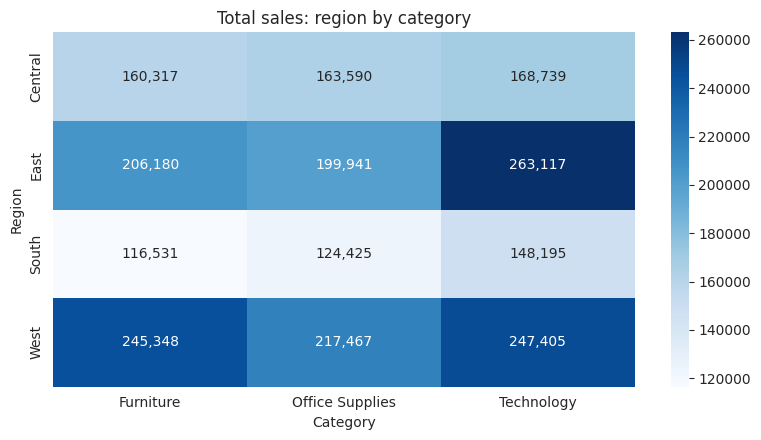

In [13]:
pivot = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")

plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="Blues")
plt.title("Total sales: region by category")
save_fig("05_region_category_heatmap")

### 5.3 Distribution of sales values and shipping time

Skewness of Sales: 12.98


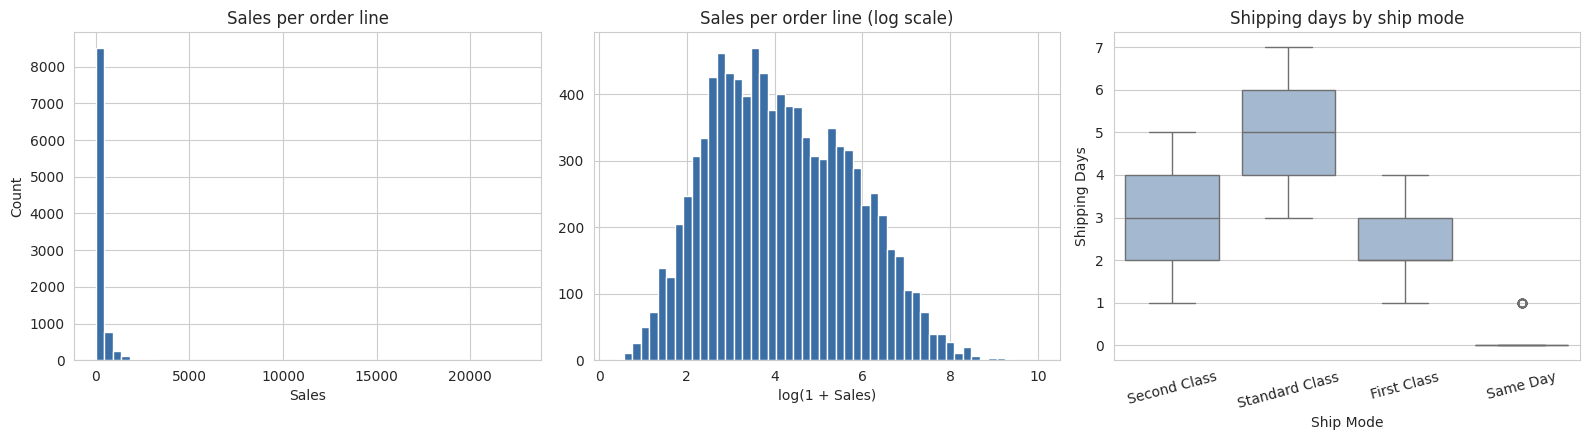

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df["Sales"], bins=50, color="#3b6ea5")
axes[0].set_title("Sales per order line")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["Sales"]), bins=50, color="#3b6ea5")
axes[1].set_title("Sales per order line (log scale)")
axes[1].set_xlabel("log(1 + Sales)")

sns.boxplot(data=df, x="Ship Mode", y="Shipping Days", ax=axes[2], color="#9db8d6")
axes[2].set_title("Shipping days by ship mode")
axes[2].tick_params(axis="x", rotation=15)
save_fig("06_distributions")

print("Skewness of Sales:", round(df["Sales"].skew(), 2))

In [15]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

results.update(
    top_category=cat_sales.index[0],
    top_category_share_pct=float(cat_sales.iloc[0] / cat_sales.sum() * 100),
    top_region=region_sales.index[0],
    top_region_share_pct=float(region_sales.iloc[0] / region_sales.sum() * 100),
    top_segment=segment_sales.index[0],
    top_segment_share_pct=float(segment_sales.iloc[0] / segment_sales.sum() * 100),
    top_subcategory=sub_sales.index[0],
    top_state=state_sales.index[0],
    sales_skew=float(df["Sales"].skew()),
    avg_shipping_days=float(df["Shipping Days"].mean()),
)

print(f"Top category : {results['top_category']} ({results['top_category_share_pct']:.1f}% of sales)")
print(f"Top region   : {results['top_region']} ({results['top_region_share_pct']:.1f}% of sales)")
print(f"Top segment  : {results['top_segment']} ({results['top_segment_share_pct']:.1f}% of sales)")
print(f"Top sub-cat  : {results['top_subcategory']}")
print(f"Top state    : {results['top_state']}")

Top category : Technology (36.6% of sales)
Top region   : West (31.4% of sales)
Top segment  : Consumer (50.8% of sales)
Top sub-cat  : Phones
Top state    : California


**EDA takeaways** (the numbers are printed above and saved in `results_summary.md`)

- Check the skewness value and the histogram: if a few very large order lines pull the average up, it is better to model the *log* of sales, which I do later.
- Check the seasonality chart: if some calendar months are consistently higher, a forecasting model should handle seasonality.
- Check whether sales are spread unevenly across categories, regions and segments: if they are, these are useful features for the models.

## 6. Customer segmentation (RFM + KMeans)

**RFM** describes each customer with three numbers:

- **Recency**: days since the customer's last order (lower is better)
- **Frequency**: number of different orders
- **Monetary**: total sales value

The three numbers are skewed, so I use `log(1 + x)` and then standardise them before running KMeans. I try several values of k and use the silhouette score to help decide. I only choose between 3 and 6 groups, because 2 groups is usually too coarse to be useful for marketing.

In [16]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
)

print("Customers:", len(rfm))
rfm.describe()

Customers: 793


,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,149.286255,6.206810,2851.520064
std,187.081466,2.525647,2620.398490
min,1.000000,1.000000,4.833000
25%,31.000000,4.000000,1081.466000
50%,76.000000,6.000000,2215.002000
75%,185.000000,8.000000,3670.258000
max,1166.000000,17.000000,25043.050000


   silhouette
2       0.350
3       0.253
4       0.255
5       0.252
6       0.243
7       0.240
Chosen k (best silhouette between 3 and 6): 4


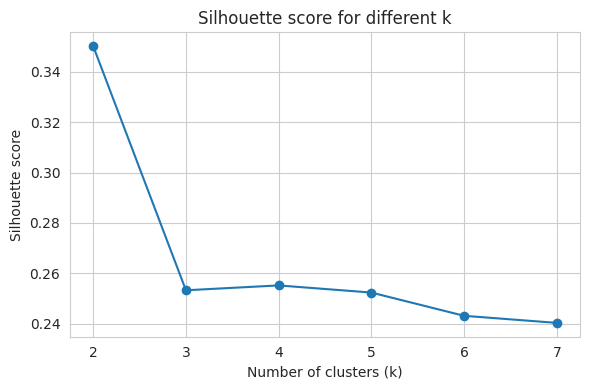

In [17]:
rfm_scaled = StandardScaler().fit_transform(np.log1p(rfm[["Recency", "Frequency", "Monetary"]]))

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, km.labels_)

sil_table = pd.Series(sil_scores, name="silhouette").round(3).to_frame()
print(sil_table)

plt.figure(figsize=(6, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.title("Silhouette score for different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
save_fig("07_silhouette")

best_k = max(range(3, 7), key=lambda k: sil_scores[k])
print("Chosen k (best silhouette between 3 and 6):", best_k)

In [18]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(rfm_scaled)
rfm["Cluster"] = kmeans.labels_

profile = rfm.groupby("Cluster").agg(
    Customers=("Monetary", "size"),
    Avg_Recency_days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Sales=("Monetary", "sum"),
)
profile["Share_of_sales_pct"] = profile["Total_Sales"] / profile["Total_Sales"].sum() * 100
profile["Share_of_customers_pct"] = profile["Customers"] / profile["Customers"].sum() * 100

# Rank the groups by average spend so the names are stable and easy to read
order = profile["Avg_Monetary"].sort_values(ascending=False).index
tier_names = {c: f"Tier {i + 1}" for i, c in enumerate(order)}
profile.insert(0, "Group", [tier_names[c] for c in profile.index])
rfm["Group"] = rfm["Cluster"].map(tier_names)

profile = profile.sort_values("Group").round(1)
profile

,Group,Customers,Avg_Recency_days,Avg_Frequency,Avg_Monetary,Total_Sales,Share_of_sales_pct,Share_of_customers_pct
Cluster,,,,,,,,
3,Tier 1,233,97.9,8.7,4908.7,1143728.0,50.6,29.4
2,Tier 2,199,20.0,6.7,2676.4,532607.7,23.6,25.1
0,Tier 3,274,223.3,4.9,1992.9,546063.4,24.1,34.6
1,Tier 4,87,349.6,2.6,446.6,38856.4,1.7,11.0


Top 20% of customers generate 48.5% of sales


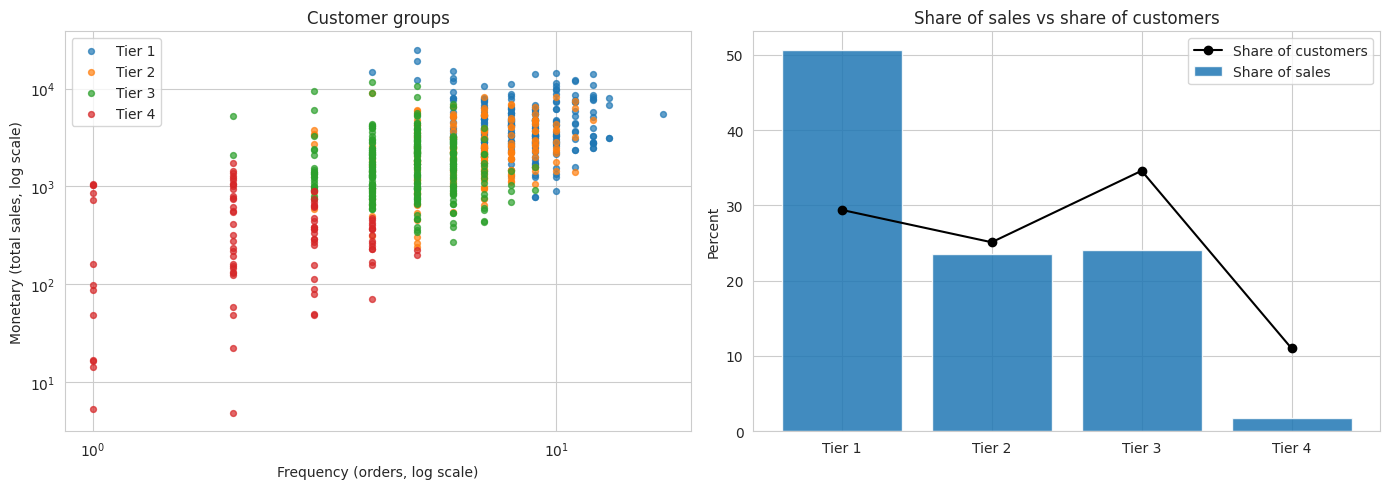

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, part in rfm.groupby("Group"):
    axes[0].scatter(part["Frequency"], part["Monetary"], s=18, alpha=0.7, label=group)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Frequency (orders, log scale)")
axes[0].set_ylabel("Monetary (total sales, log scale)")
axes[0].set_title("Customer groups")
axes[0].legend()

axes[1].bar(profile["Group"], profile["Share_of_sales_pct"], label="Share of sales", alpha=0.85)
axes[1].plot(profile["Group"], profile["Share_of_customers_pct"], color="black", marker="o", label="Share of customers")
axes[1].set_ylabel("Percent")
axes[1].set_title("Share of sales vs share of customers")
axes[1].legend()
save_fig("08_customer_groups")

# Pareto check: how much of the sales comes from the top 20% of customers?
sorted_m = rfm["Monetary"].sort_values(ascending=False)
top20_share = sorted_m.head(int(np.ceil(len(sorted_m) * 0.2))).sum() / sorted_m.sum() * 100
print(f"Top 20% of customers generate {top20_share:.1f}% of sales")

results["rfm_best_k"] = int(best_k)
results["rfm_silhouette"] = float(sil_scores[best_k])
results["top20_customers_share_pct"] = float(top20_share)
results["rfm_groups"] = profile.reset_index(drop=True).to_dict(orient="records")

**How to read this:** Tier 1 is the group with the highest average spend. Look at the table to see how recency and frequency differ between the tiers. A marketing team could give the top tier loyalty rewards and try to win back customers in the group with the longest time since their last order.

## 7. Monthly sales forecasting

Sales are added up per month. To test the models fairly I use a **time-based split**: the model is trained on the past and tested on the **last 6 months**, which it has never seen. (A random split would be wrong for time series, because it lets the model see the future.)

Models compared:

| Model | Idea |
|---|---|
| Naive | next months = last month |
| 3-month moving average | next months = average of the last 3 months |
| Seasonal naive | next months = same month last year |
| Linear trend + monthly seasonality | a straight-line trend plus a value for each calendar month |
| Holt-Winters | exponential smoothing with trend and seasonality (only if `statsmodels` is installed) |

Months of data: 48


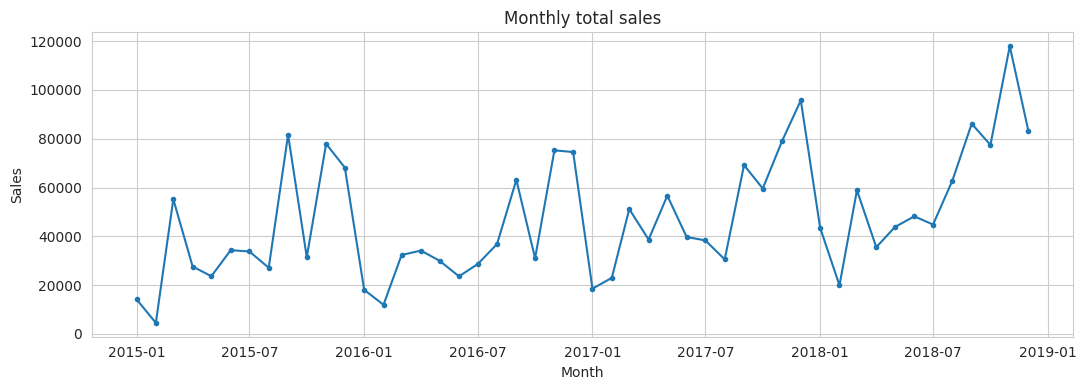

In [20]:
monthly = df.set_index("Order Date")["Sales"].resample("MS").sum()
print("Months of data:", len(monthly))

plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly.values, marker="o", markersize=3)
plt.title("Monthly total sales")
plt.xlabel("Month")
plt.ylabel("Sales")
save_fig("09_monthly_sales")

In [21]:
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
print("statsmodels available:", HAS_STATSMODELS)


def forecast_model(name, train, future_idx):
    # Return a forecast (as a Series) for the dates in future_idx using only the training data
    if name == "Naive (last month)":
        return pd.Series(train.iloc[-1], index=future_idx)

    if name == "3-month moving average":
        return pd.Series(train.iloc[-3:].mean(), index=future_idx)

    if name == "Seasonal naive (same month last year)":
        values = []
        for d in future_idx:
            ref = d - pd.DateOffset(months=12)
            while ref not in train.index and ref > train.index[0]:
                ref = ref - pd.DateOffset(months=12)
            values.append(train.get(ref, train.mean()))
        return pd.Series(values, index=future_idx)

    if name == "Linear trend + monthly seasonality":
        def make_features(idx):
            t = ((idx.year - train.index[0].year) * 12 + (idx.month - train.index[0].month)).values
            month_dummies = np.zeros((len(idx), 12))
            month_dummies[np.arange(len(idx)), idx.month - 1] = 1
            return np.column_stack([t, month_dummies])

        model = LinearRegression(fit_intercept=False).fit(make_features(train.index), train.values)
        return pd.Series(model.predict(make_features(future_idx)), index=future_idx)

    if name == "Holt-Winters":
        fit = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
        return pd.Series(fit.forecast(len(future_idx)).values, index=future_idx)

    raise ValueError(name)


model_names = [
    "Naive (last month)",
    "3-month moving average",
    "Seasonal naive (same month last year)",
    "Linear trend + monthly seasonality",
]
if HAS_STATSMODELS and len(monthly) >= 30:
    model_names.append("Holt-Winters")

statsmodels available: False


In [22]:
horizon = 6 if len(monthly) >= 30 else 3
train, test = monthly.iloc[:-horizon], monthly.iloc[-horizon:]
print(f"Training months: {len(train)}   Test months: {len(test)} ({test.index[0].strftime('%b %Y')} to {test.index[-1].strftime('%b %Y')})")

rows, test_preds = [], {}
for name in model_names:
    try:
        pred = forecast_model(name, train, test.index)
    except Exception as e:
        print("Skipped", name, "->", e)
        continue
    test_preds[name] = pred
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(test, pred),
        "RMSE": np.sqrt(mean_squared_error(test, pred)),
        "MAPE %": np.mean(np.abs((test - pred) / test)) * 100,
    })

forecast_table = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
forecast_table.round(1)

Training months: 42   Test months: 6 (Jul 2018 to Dec 2018)


,Model,MAE,RMSE,MAPE %
0,Linear trend + monthly seasonality,14668.1,18485.0,17.6
1,Seasonal naive (same month last year),20867.5,23680.6,26.2
2,Naive (last month),31636.6,37862.7,35.6
3,3-month moving average,36185.9,42565.9,41.0


Best model on the test months (lowest MAE): Linear trend + monthly seasonality


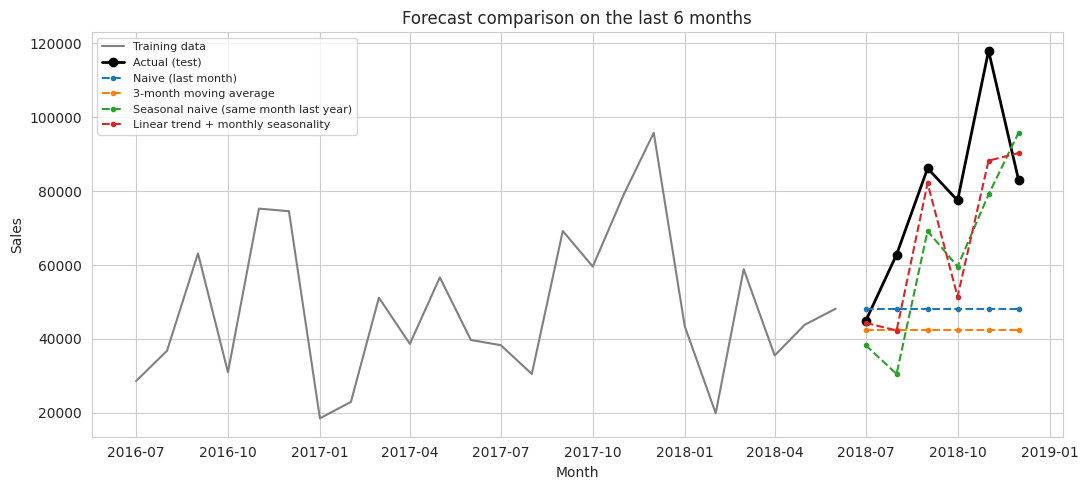

In [23]:
plt.figure(figsize=(11, 5))
history = train.iloc[-24:]
plt.plot(history.index, history.values, color="grey", label="Training data")
plt.plot(test.index, test.values, color="black", marker="o", linewidth=2, label="Actual (test)")
for name, pred in test_preds.items():
    plt.plot(pred.index, pred.values, marker=".", linestyle="--", label=name)
plt.title(f"Forecast comparison on the last {horizon} months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(fontsize=8)
save_fig("10_forecast_comparison")

best_forecast_model = forecast_table.loc[0, "Model"]
print("Best model on the test months (lowest MAE):", best_forecast_model)

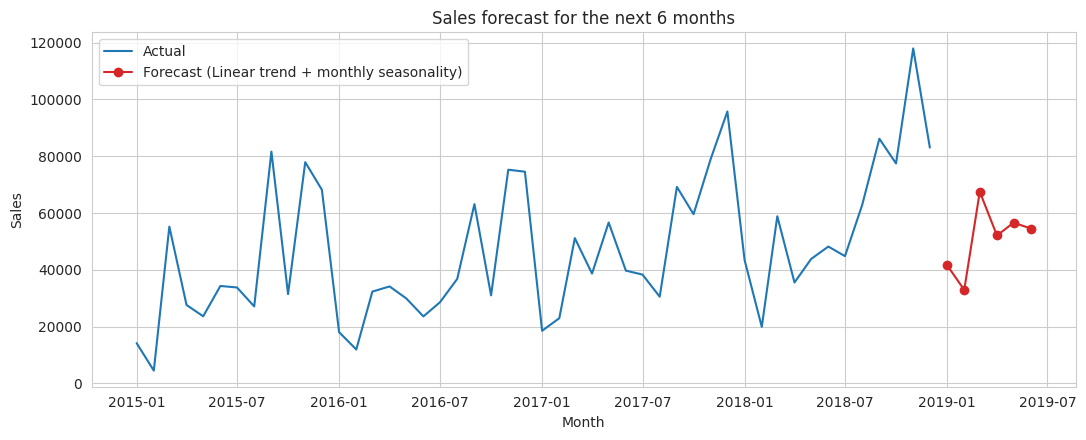

,Forecast sales
2019-01-01,41660.0
2019-02-01,32930.0
2019-03-01,67481.0
2019-04-01,52088.0
2019-05-01,56609.0
2019-06-01,54547.0


In [24]:
# Refit the best model on ALL the data and forecast the next 6 months
future_idx = pd.date_range(monthly.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq="MS")
next_forecast = forecast_model(best_forecast_model, monthly, future_idx)

plt.figure(figsize=(11, 4.5))
plt.plot(monthly.index, monthly.values, label="Actual")
plt.plot(next_forecast.index, next_forecast.values, marker="o", color="tab:red", label=f"Forecast ({best_forecast_model})")
plt.title("Sales forecast for the next 6 months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
save_fig("11_next_6_months_forecast")

next_forecast.round(0).to_frame("Forecast sales")

In [25]:
results["forecast_horizon_months"] = int(horizon)
results["forecast_models"] = forecast_table.round(2).to_dict(orient="records")
results["forecast_best_model"] = best_forecast_model
results["forecast_next_6_months"] = {d.strftime("%Y-%m"): float(v) for d, v in next_forecast.items()}

**Note:** with only a few years of monthly data, any seasonal model is estimating each calendar month from just a handful of points. The forecast should be seen as a planning guide with uncertainty, not an exact number.

## 8. Predicting the value of an order line

In Week 11 I used Linear Regression on the raw `Sales` value. Two things can be improved:

1. `Sales` is usually right-skewed (see the EDA), so I predict `log(1 + Sales)` instead and convert back when reporting errors.
2. I compare a few stronger models against a **baseline that always predicts the average**, and I use 5-fold cross-validation on the training data to choose the best model (so the test set is only used once, at the end).

Features (all known when the order is placed): ship mode, customer segment, region, state, category, sub-category, order year, order month, order weekday and shipping days.

In [26]:
cat_features = ["Ship Mode", "Segment", "Region", "State", "Category", "Sub-Category"]
num_features = ["Order Year", "Order Month", "Order Weekday", "Shipping Days"]

X = df[cat_features + num_features]
y = df["Sales"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, ylog_train, ylog_test = train_test_split(
    X, y, y_log, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "  Test:", X_test.shape)


def make_pipeline(model):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ("num", StandardScaler(), num_features),
    ])
    return Pipeline([("prep", pre), ("model", model)])

Train: (7839, 10)   Test: (1960, 10)


In [27]:
candidates = {
    "Baseline (always predict the average)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE),
}

fitted, cv_r2 = {}, {}
for name, model in candidates.items():
    pipe = make_pipeline(model)
    if not name.startswith("Baseline"):
        cv_r2[name] = cross_val_score(pipe, X_train, ylog_train, cv=5, scoring="r2").mean()
    pipe.fit(X_train, ylog_train)
    fitted[name] = pipe

pd.Series(cv_r2, name="Mean 5-fold CV R2 (log sales)").round(4).to_frame()

,Mean 5-fold CV R2 (log sales)
Linear Regression,0.4512
Random Forest,0.4328
Gradient Boosting,0.4404


In [28]:
rows = []
for name, pipe in fitted.items():
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 (original scale)": r2_score(y_test, pred),
        "R2 (log scale)": r2_score(ylog_test, pred_log),
    })

# The Week 11 approach again, for comparison: Linear Regression on the raw Sales value
week11 = make_pipeline(LinearRegression()).fit(X_train, y_train)
p11 = week11.predict(X_test)
rows.append({
    "Model": "Linear Regression on raw Sales (Week 11 approach)",
    "MAE": mean_absolute_error(y_test, p11),
    "RMSE": np.sqrt(mean_squared_error(y_test, p11)),
    "R2 (original scale)": r2_score(y_test, p11),
    "R2 (log scale)": r2_score(ylog_test, np.log1p(np.clip(p11, 0, None))),
})

model_table = pd.DataFrame(rows)
model_table.round(4)

,Model,MAE,RMSE,R2 (original scale),R2 (log scale)
0,Baseline (always predict the average),229.8545,778.5744,-0.0608,-0.0001
1,Linear Regression,196.2232,729.7956,0.0679,0.4465
2,Random Forest,196.4233,728.4801,0.0713,0.4371
3,Gradient Boosting,194.7547,725.4372,0.0790,0.4517
4,Linear Regression on raw Sales (Week 11 approach),232.7699,700.0884,0.1423,-0.1730


Best model by cross-validation: Linear Regression


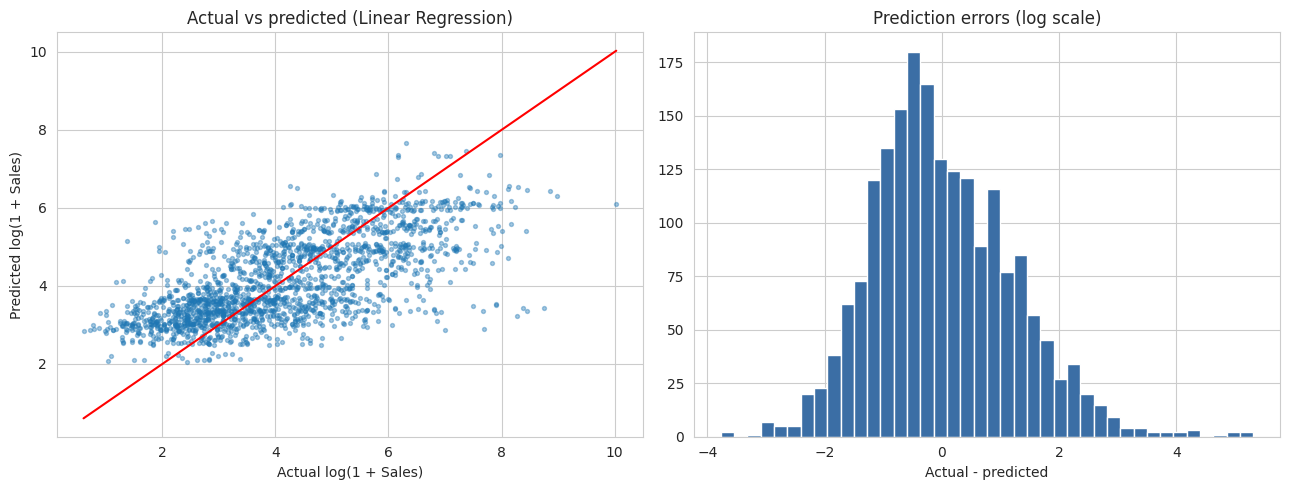

In [29]:
# Choose the best model using cross-validation on the training data (not the test set)
best_model_name = max(cv_r2, key=cv_r2.get)
best_pipe = fitted[best_model_name]
print("Best model by cross-validation:", best_model_name)

pred_log = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(ylog_test, pred_log, s=8, alpha=0.4)
lims = [min(ylog_test.min(), pred_log.min()), max(ylog_test.max(), pred_log.max())]
axes[0].plot(lims, lims, color="red")
axes[0].set_xlabel("Actual log(1 + Sales)")
axes[0].set_ylabel("Predicted log(1 + Sales)")
axes[0].set_title(f"Actual vs predicted ({best_model_name})")

axes[1].hist(ylog_test - pred_log, bins=40, color="#3b6ea5")
axes[1].set_title("Prediction errors (log scale)")
axes[1].set_xlabel("Actual - predicted")
save_fig("12_order_model_fit")

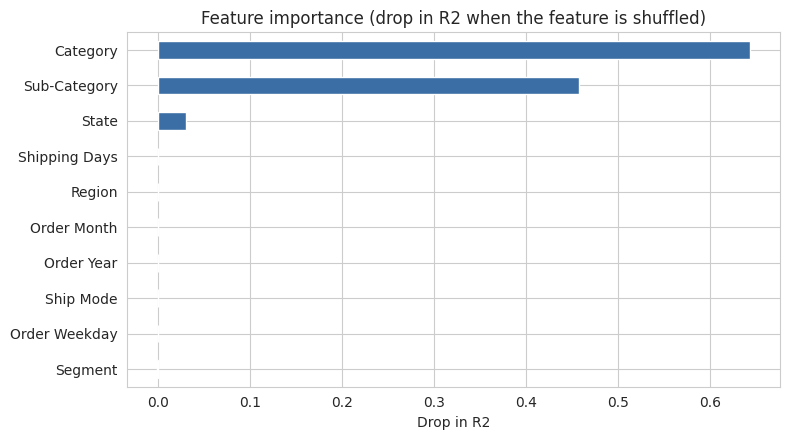

,Importance
Category,0.6439
Sub-Category,0.4580
State,0.0308
Shipping Days,0.0005
Region,0.0004
Order Month,0.0001
Order Year,0.0000
Ship Mode,-0.0002
Order Weekday,-0.0002
Segment,-0.0009


In [30]:
# Which original features matter most? Permutation importance on the test set:
# shuffle one feature at a time and see how much the score drops.
perm = permutation_importance(best_pipe, X_test, ylog_test, n_repeats=5, random_state=RANDOM_STATE, scoring="r2")
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
importance.sort_values().plot(kind="barh", color="#3b6ea5")
plt.title("Feature importance (drop in R2 when the feature is shuffled)")
plt.xlabel("Drop in R2")
save_fig("13_feature_importance")

importance.round(4).to_frame("Importance")

In [31]:
best_row = model_table[model_table["Model"] == best_model_name].iloc[0]
results["order_models"] = model_table.round(4).to_dict(orient="records")
results["order_cv_r2"] = {k: float(v) for k, v in cv_r2.items()}
results["order_best_model"] = best_model_name
results["order_best_test_r2_log"] = float(best_row["R2 (log scale)"])
results["order_best_test_r2_original"] = float(best_row["R2 (original scale)"])
results["order_best_test_mae"] = float(best_row["MAE"])
results["order_top_features"] = [(k, float(v)) for k, v in importance.head(5).items()]

**How to read this:** compare each model against the baseline row. If the R2 values are low, that is an honest result: the data only has categories, dates and location. It does **not** contain quantity, discount or price, which are the main drivers of an order's value. This is the biggest limit of the model.

## 9. Save the results

In [32]:
lines = []
lines.append("# Results summary\n")
lines.append("_This file is generated by the notebook. Re-run the notebook to refresh it._\n")

lines.append("## Data")
lines.append(f"- Rows: {results['rows_raw']:,} raw, {results['rows_clean']:,} after cleaning")
lines.append(f"- Period: {results['date_min']} to {results['date_max']}")
lines.append(f"- Total sales: {results['total_sales']:,.0f} across {results['n_orders']:,} orders and {results['n_customers']:,} customers")
lines.append(f"- Average order value: {results['avg_order_value']:,.2f}\n")

lines.append("## EDA")
lines.append(f"- Top category: {results['top_category']} ({results['top_category_share_pct']:.1f}% of sales)")
lines.append(f"- Top region: {results['top_region']} ({results['top_region_share_pct']:.1f}% of sales)")
lines.append(f"- Top customer segment: {results['top_segment']} ({results['top_segment_share_pct']:.1f}% of sales)")
lines.append(f"- Top sub-category: {results['top_subcategory']}; top state: {results['top_state']}")
lines.append(f"- Strongest month on average: {results['best_month']}; weakest: {results['worst_month']}")
growth = ", ".join(f"{y}: {v:+.1f}%" for y, v in results["yoy_growth_pct"].items())
lines.append(f"- Year-on-year sales growth: {growth}\n")

lines.append("## Customer segmentation")
lines.append(f"- KMeans on log-scaled RFM, k = {results['rfm_best_k']} (silhouette {results['rfm_silhouette']:.3f})")
lines.append(f"- Top 20% of customers generate {results['top20_customers_share_pct']:.1f}% of sales")
for g in results["rfm_groups"]:
    lines.append(
        f"- {g['Group']}: {g['Customers']:.0f} customers, avg recency {g['Avg_Recency_days']:.0f} days, "
        f"avg {g['Avg_Frequency']:.1f} orders, {g['Share_of_sales_pct']:.1f}% of sales"
    )
lines.append("")

lines.append(f"## Forecasting (test on last {results['forecast_horizon_months']} months)")
for m in results["forecast_models"]:
    lines.append(f"- {m['Model']}: MAE {m['MAE']:,.0f}, RMSE {m['RMSE']:,.0f}, MAPE {m['MAPE %']:.1f}%")
lines.append(f"- Best model: {results['forecast_best_model']}")
lines.append("- Forecast for the next 6 months: " + ", ".join(f"{k}: {v:,.0f}" for k, v in results["forecast_next_6_months"].items()) + "\n")

lines.append("## Order value prediction (target: log of sales)")
for m in results["order_models"]:
    lines.append(f"- {m['Model']}: R2 (log) {m['R2 (log scale)']:.3f}, R2 (original) {m['R2 (original scale)']:.3f}, MAE {m['MAE']:,.1f}")
lines.append(f"- Best model by cross-validation: {results['order_best_model']}")
lines.append("- Most important features: " + ", ".join(f"{k} ({v:.3f})" for k, v in results["order_top_features"]))

with open("results_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, default=str)

print("\n".join(lines))

# Results summary

_This file is generated by the notebook. Re-run the notebook to refresh it._

## Data
- Rows: 9,800 raw, 9,799 after cleaning
- Period: 2015-01-03 to 2018-12-30
- Total sales: 2,261,255 across 4,922 orders and 793 customers
- Average order value: 459.42

## EDA
- Top category: Technology (36.6% of sales)
- Top region: West (31.4% of sales)
- Top customer segment: Consumer (50.8% of sales)
- Top sub-category: Phones; top state: California
- Strongest month on average: November; weakest: February
- Year-on-year sales growth: 2016: -4.2%, 2017: +30.6%, 2018: +20.3%

## Customer segmentation
- KMeans on log-scaled RFM, k = 4 (silhouette 0.255)
- Top 20% of customers generate 48.5% of sales
- Tier 1: 233 customers, avg recency 98 days, avg 8.7 orders, 50.6% of sales
- Tier 2: 199 customers, avg recency 20 days, avg 6.7 orders, 23.6% of sales
- Tier 3: 274 customers, avg recency 223 days, avg 4.9 orders, 24.1% of sales
- Tier 4: 87 customers, avg recency 350 days, avg 2.6 

## 10. Conclusions

*These numbers are from my run on the Kaggle Superstore `train.csv` file (9,800 rows, 2015-2018). They are also saved in `results_summary.md`.*

**Customers**

- Sales grew from about 459k in 2016 to 722k in 2018. Technology is the biggest category (36.6% of sales), West is the biggest region (31.4%), Consumers give 50.8% of sales, and November is the strongest month on average.
- KMeans found **4 customer groups**. Tier 1 is 29% of customers but **51% of sales**. Tier 2 bought most recently (20 days ago on average). Tier 3 is 35% of customers with 24% of sales but has been away for about 223 days, so it is the best group to win back. Tier 4 is 11% of customers but only 1.7% of sales and has been away for about 350 days.
- The silhouette score is only 0.255, so the groups overlap: customers form more of a continuum than clear separate clusters. The top 20% of customers give 48.5% of sales, which is less concentrated than the "80/20 rule".

**Forecast**

- The best model was **linear trend + monthly seasonality**: on the last 6 months its average error (MAPE) was 17.6%, compared with 26.1% for seasonal naive and 35.6% for the naive model. A 17.6% error is useful for planning but not exact. The chart shows the model was below the actual sales in most of the 6 test months, when sales were growing fast, so the 2019 forecast may also be on the low side if that growth continues.
- The forecast for the next 6 months (Jan-Jun 2019) is between about 33k and 67k per month, with March the highest. This is only tested on one 6-month window.

**Order value**

- All three models that use log sales reach about 0.44-0.45 R2 on the log scale, while the average baseline gets 0. So category and sub-category (and a little the state) explain a good part of the value of an order line.
- The three models are almost equal, so cross-validation chose the simplest one, **Linear Regression** (test MAE about 196).
- Compared with my Week 11 approach: the log model has a smaller typical error (MAE 196 vs 233), but the Week 11 model has a higher R2 on the original scale (0.14 vs 0.07), because the log model under-predicts very large orders. Both R2 values on the original scale are low: very large orders cannot be predicted without quantity, price or discount.

**Business advice**

1. Protect Tier 1 and Tier 2 customers with loyalty offers and win back Tier 3 with a targeted campaign.
2. Use the forecast as a planning guide for stock, with a safety margin of roughly the forecast error.
3. Collect quantity, discount and profit so that profit (not just sales) can be predicted.

## 11. Limitations and what I would improve with more time

**Limitations**

- The data has no quantity, discount, price or profit columns, so the order value model can only use categories and dates. This limits how accurate it can be.
- Only a few years of monthly data are available, so seasonality is estimated from very few points and the forecast comes with real uncertainty.
- The forecast uses one 6-month test period. A single test window can be lucky or unlucky.
- The order-level split is random, so several lines of the same order can end up in both train and test.
- The customer groups are based only on past buying behaviour, and the tier names are just based on average spend.

**With more time I would**

1. Add quantity, discount and profit data and predict **profit**, not only sales.
2. Use rolling-origin (walk-forward) validation for the forecast and compare more models such as SARIMA or Prophet.
3. Forecast per category or region and combine them.
4. Split the order data by customer or by time to avoid leakage between train and test.
5. Build an interactive dashboard (for example Streamlit) so the business team can explore the results themselves.
6. Test the customer groups with a real campaign (A/B test) to see whether targeting them changes sales.